In [49]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load the Dataset
response_df = pd.read_excel("datasets/cleaned_response_dataset.xlsx",index_col=0)

response_df.info()

graph_save_path= "Graphs/descriptive_analysis/"

<class 'pandas.DataFrame'>
Index: 159 entries, 0 to 160
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Timestamp                       159 non-null    datetime64[us]
 1   faculty                         159 non-null    str           
 2   device_type                     159 non-null    str           
 3   brand_name                      159 non-null    str           
 4   chosen_method                   159 non-null    str           
 5   normal_use_battery_life(hours)  159 non-null    int64         
 6   budget                          159 non-null    int64         
 7   device_price                    159 non-null    int64         
 8   payment_method                  159 non-null    str           
 9   storage_capacity(GB)            159 non-null    int64         
 10  expected_life_span(years)       159 non-null    int64         
 11  research_time         

In [50]:
# Spliting Numerical and Categorical columns
num_cols = [col for col in response_df.columns if response_df[col].dtype == "int64"]

cat_cols = []
for col in response_df.columns:
    if col not in num_cols:
        if response_df[col].nunique() < 20:
            response_df[col] = response_df[col].astype("category")
            cat_cols.append(col)


print(num_cols)
print(cat_cols)

print(response_df.info())

['normal_use_battery_life(hours)', 'budget', 'device_price', 'storage_capacity(GB)', 'expected_life_span(years)', 'weight(g)', 'satisfaction', 'ram_capacity(GB)']
['faculty', 'device_type', 'brand_name', 'chosen_method', 'payment_method', 'research_time', 'primary_influence', 'store_type']
<class 'pandas.DataFrame'>
Index: 159 entries, 0 to 160
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Timestamp                       159 non-null    datetime64[us]
 1   faculty                         159 non-null    category      
 2   device_type                     159 non-null    category      
 3   brand_name                      159 non-null    category      
 4   chosen_method                   159 non-null    category      
 5   normal_use_battery_life(hours)  159 non-null    int64         
 6   budget                          159 non-null    int64         
 7   dev

# Summary Tables

In [51]:
# Numerical Summarries
print("--Numerical Column Summaries---\n")
print(response_df.describe())

--Numerical Column Summaries---

                        Timestamp  normal_use_battery_life(hours)  \
count                         159                      159.000000   
mean   2026-06-18 19:45:56.263528                        9.044025   
min    2026-06-13 10:31:53.030000                        2.000000   
25%    2026-06-16 22:49:06.523500                        5.000000   
50%    2026-06-17 10:17:07.419000                        8.000000   
75%    2026-06-18 10:02:34.540000                       12.000000   
max    2026-07-09 17:14:58.739000                       24.000000   
std                           NaN                        4.950829   

              budget   device_price  storage_capacity(GB)  \
count     159.000000     159.000000            159.000000   
mean   200327.037736  207553.452830            490.918239   
min     20000.000000   20000.000000              8.000000   
25%    120000.000000  132000.000000            256.000000   
50%    200000.000000  210000.000000     

In [52]:
# Categorical FrequenciesOutput
print("--Categorical Frequencies--")

for col in cat_cols:
    print(f"=={col.upper()}==")
    counts = response_df[col].value_counts()
    percentages = response_df[col].value_counts(normalize=True).mul(100).round(2).astype(str)

    cat_summary_table = pd.DataFrame({
        "Counts":counts,
        "Percentages":percentages
    })
    print(cat_summary_table)
    print("\n\n")


--Categorical Frequencies--
==FACULTY==
                                           Counts Percentages
faculty                                                      
Faculty Of Computing                           67       42.14
Faculty Of Engineering                         36       22.64
Faculty Of Humanities And Social Sciences      28       17.61
Faculty Of Management Sciences                 14        8.81
Faculty Of Medical Sciences                    14        8.81



==DEVICE_TYPE==
                           Counts Percentages
device_type                                  
Laptop / Desktop Computer      94       59.12
Mobile Phone                   51       32.08
Tablet                         14        8.81



==BRAND_NAME==
              Counts Percentages
brand_name                      
Asus              33       20.75
Samsung           27       16.98
Apple             24       15.09
Hp                19       11.95
Lenovo            15        9.43
Msi               12        

# Visualizations


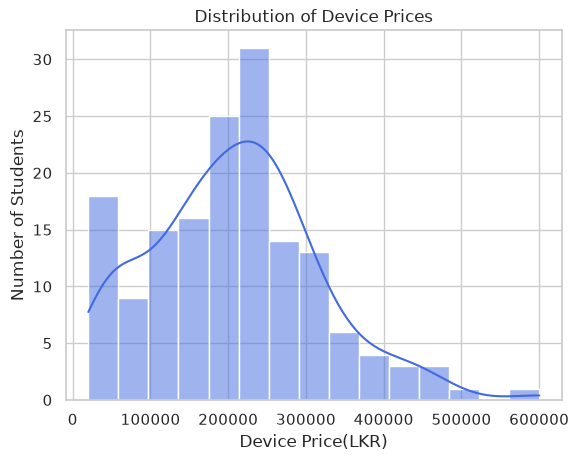

In [53]:
fig,axes = plt.subplots(1,1)
sns.set_theme(style="whitegrid")

# Histogram of device_price
sns.histplot(data=response_df,x="device_price",bins=15, kde=True, color="royalblue", ax=axes)
axes.set_title("Distribution of Device Prices")
axes.set_xlabel("Device Price(LKR)")
axes.set_ylabel("Number of Students")

plt.savefig(f"{graph_save_path}histogram_device_price.png")

plt.show()

/tmp/ipykernel_26024/1852590464.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=response_df,


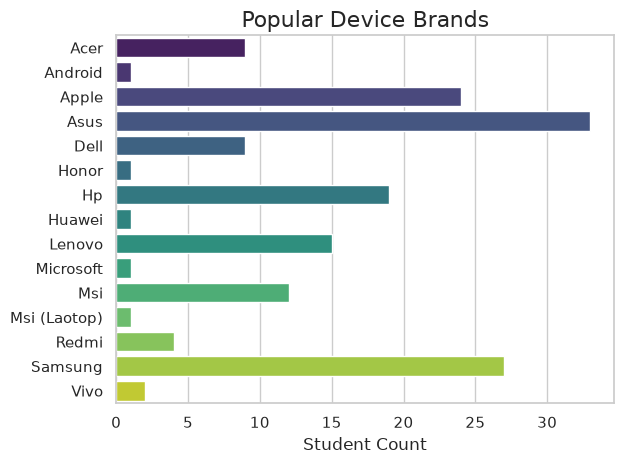

/tmp/ipykernel_26024/1852590464.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=response_df,


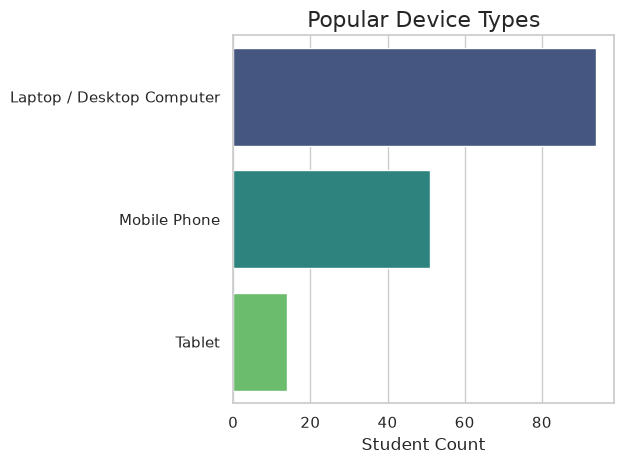

/tmp/ipykernel_26024/1852590464.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=response_df,


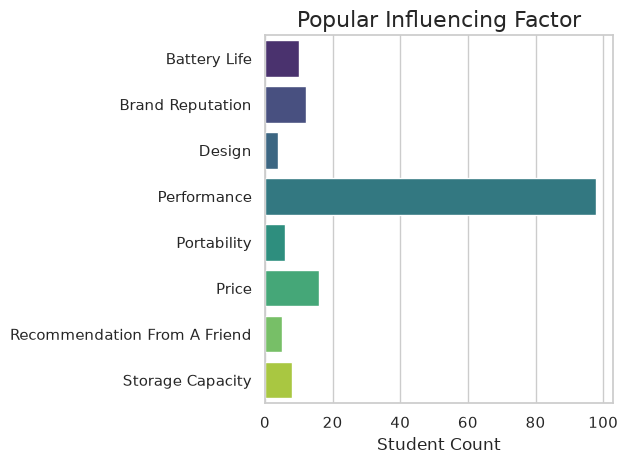

/tmp/ipykernel_26024/1852590464.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=response_df,


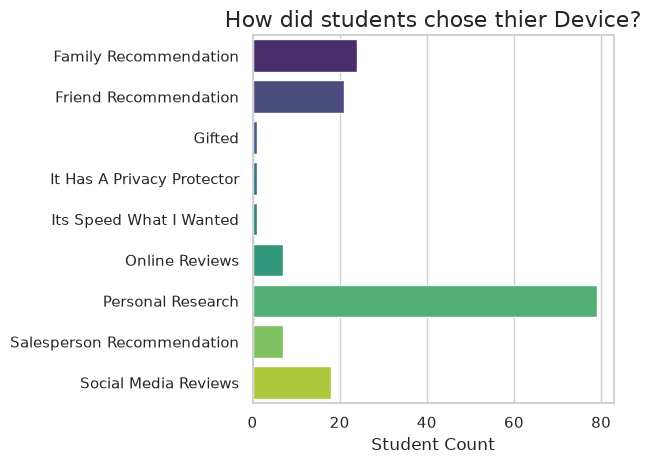

In [54]:
# Bar Charts


cat_cols_to_plot = ["brand_name","device_type","primary_influence","chosen_method"]
plot_tiles = ["Popular Device Brands", "Popular Device Types", "Popular Influencing Factor", "How did students chose thier Device?"]

col_to_plot_ind = 0

for i in range(len(cat_cols_to_plot)):
    fig,axes = plt.subplots()
    col = cat_cols_to_plot[i]
    title = cat_cols_to_plot[i]

    sns.countplot(data=response_df,
                      y=cat_cols_to_plot[col_to_plot_ind],
                        palette="viridis")
    plt.title(plot_tiles[col_to_plot_ind],fontsize=16)
    plt.xlabel("Student Count",fontsize=12)
    plt.ylabel("")# cat_cols_to_plot[col_to_plot_ind].upper().replace("_"," "),fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{graph_save_path}{col}_vs_popularity.png")
    plt.show()

    col_to_plot_ind += 1





/tmp/ipykernel_26024/1742171723.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=response_df,x="faculty",y="device_price",palette="Set2")
/tmp/ipykernel_26024/1742171723.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45)


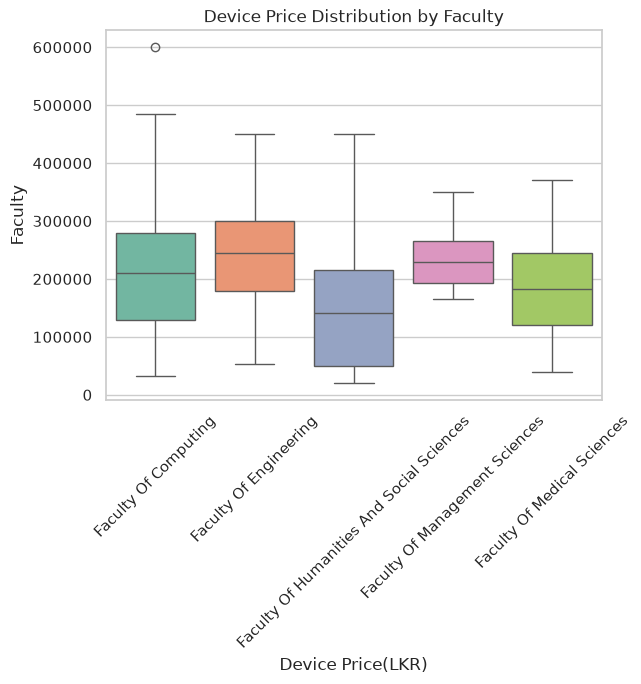

In [55]:
# Box Plot Price vs Faculty

fig,ax = plt.subplots()

sns.boxplot(data=response_df,x="faculty",y="device_price",palette="Set2")
ax.set_title("Device Price Distribution by Faculty")
ax.set_xlabel("Device Price(LKR)")
ax.set_ylabel("Faculty")
ax.set_xticklabels(ax.get_xticklabels(),rotation=45)
plt.savefig(f"{graph_save_path}box_plot_price_vs_faculty.png")
plt.show()

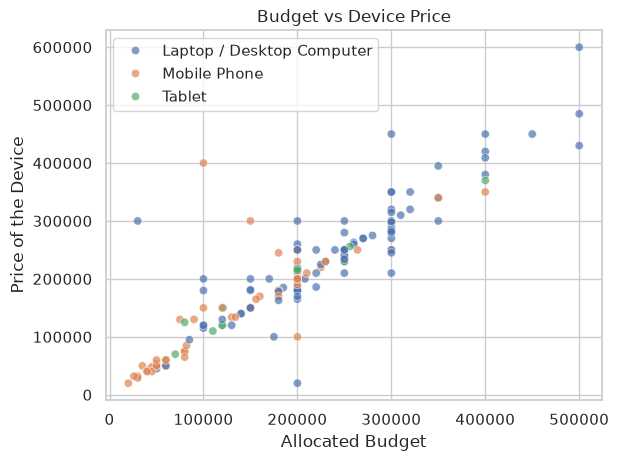

In [56]:
# Scatter Plot for Price vs Budget

fig,ax = plt.subplots()

sns.scatterplot(data=response_df,y="device_price",x="budget",hue="device_type",alpha=0.7)
ax.set_title("Budget vs Device Price")
ax.set_ylabel("Price of the Device")
ax.set_xlabel("Allocated Budget")
ax.legend()
plt.savefig(f"{graph_save_path}scatter_plot_price_vs_budget.png")
plt.show()